In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))


In [13]:
from src.rescue_route.map.map_loader import load_map
import numpy as np
import matplotlib.pyplot as plt

map_data = load_map("manhattan32")

print("Name:", map_data.name)
print("Size:", map_data.width, "x", map_data.height)

print("Base cells:", len(map_data.base_locations))
print("NFZ cells:", map_data.nfz_mask.sum())
print("Fly-over building cells:", map_data.fly_over_building_mask.sum())
print("Blocked cells:", map_data.blocked_mask.sum())
print("Free cells:", map_data.free_mask.sum())

Name: manhattan32
Size: 32 x 32
Base cells: 18
NFZ cells: 70
Fly-over building cells: 105
Blocked cells: 149
Free cells: 875


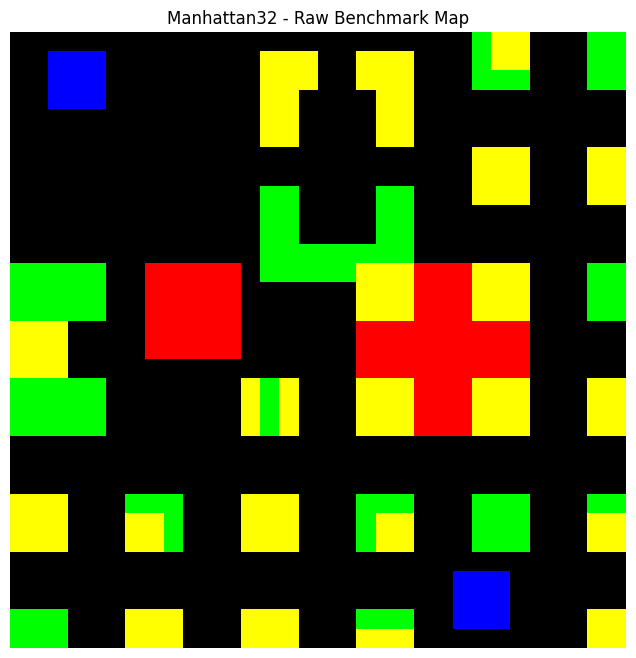

In [14]:
plt.figure(figsize=(8, 8))
plt.imshow(map_data.raw_image)
plt.title("Manhattan32 - Raw Benchmark Map")
plt.axis("off")
plt.show()

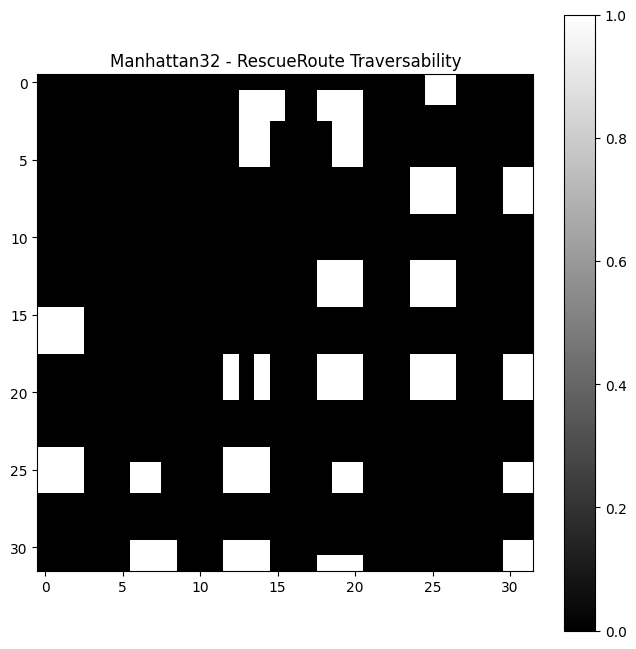

In [15]:
plt.figure(figsize=(8, 8))
plt.imshow(map_data.grid_map, cmap="gray")
plt.title("Manhattan32 - RescueRoute Traversability")
plt.colorbar()
plt.show()

In [16]:
print(map_data.base_locations[:20])

[(2, 1), (3, 1), (4, 1), (2, 2), (3, 2), (4, 2), (2, 3), (3, 3), (4, 3), (23, 28), (24, 28), (25, 28), (23, 29), (24, 29), (25, 29), (23, 30), (24, 30), (25, 30)]


In [17]:
map_data = load_map("manhattan32")

print("Name:", map_data.name)
print("Size:", map_data.width, "x", map_data.height)
print("Base cells:", len(map_data.base_locations))
print("NFZ cells:", map_data.nfz_mask.sum())
print("Fly-over building cells:", map_data.fly_over_building_mask.sum())
print("Blocked cells:", map_data.blocked_mask.sum())
print("Free cells:", map_data.free_mask.sum())

Name: manhattan32
Size: 32 x 32
Base cells: 18
NFZ cells: 70
Fly-over building cells: 105
Blocked cells: 149
Free cells: 875


In [18]:
print("Base inside blocked:",
      np.any(map_data.base_mask & map_data.blocked_mask))

Base inside blocked: False


In [19]:
print("Blocked cells consistency:",
      map_data.blocked_mask.sum() == (
          map_data.nfz_mask | map_data.raw_image.any(axis=-1) * False
      ).sum())

Blocked cells consistency: False


In [20]:
expected_blocked = map_data.nfz_mask | np.all(
    map_data.raw_image == [255, 255, 0],
    axis=-1
)

print(
    "Blocked mask correct:",
    np.array_equal(map_data.blocked_mask, expected_blocked)
)

Blocked mask correct: False


In [3]:
from src.rescue_route.map.map_loader import load_map

In [4]:
map_data = load_map("manhattan32")

print("Name:", map_data.name)
print("Size:", map_data.width, "x", map_data.height)
print("Base cells:", len(map_data.base_locations))
print("NFZ cells:", map_data.nfz_mask.sum())
print("Fly-over building cells:", map_data.fly_over_building_mask.sum())
print("Blocked cells:", map_data.blocked_mask.sum())
print("Free cells:", map_data.free_mask.sum())

Name: manhattan32
Size: 32 x 32
Base cells: 18
NFZ cells: 70
Fly-over building cells: 105
Blocked cells: 219
Free cells: 805


In [5]:
import inspect
from src.rescue_route.map import map_loader

print(inspect.getsource(map_loader.load_map))

def load_map(
    map_name: str = "manhattan32",
    base_dir: Optional[str] = None,
) -> MapData:
    """
    Load and parse a RescueRoute benchmark map.

    Expected directory:

        data/
        └── maps/
            └── <map_name>/
                ├── map.png
                └── config.json

    Parameters
    ----------
    map_name:
        Map directory name, for example:
        "manhattan32" or "urban50"

    base_dir:
        Optional repository root override.

    Returns
    -------
    MapData
        Parsed map representation.
    """

    # -------------------------------------------------------------
    # Resolve paths
    # -------------------------------------------------------------

    if base_dir is None:
        root = _project_root()
    else:
        root = Path(base_dir).resolve()

    map_folder = root / "data" / "maps" / map_name

    png_path = map_folder / "map.png"
    json_path = map_folder / "config.json"

    if not png_path.exists():
        rai

In [6]:
import numpy as np

red_mask = np.all(
    map_data.raw_image == [255, 0, 0],
    axis=-1
)

yellow_mask = np.all(
    map_data.raw_image == [255, 255, 0],
    axis=-1
)

expected_blocked = red_mask | yellow_mask

print("NFZ pixels:", red_mask.sum())
print("Yellow pixels:", yellow_mask.sum())
print("Expected blocked:", expected_blocked.sum())
print("Actual blocked:", map_data.blocked_mask.sum())

print(
    "Blocked mask correct:",
    np.array_equal(map_data.blocked_mask, expected_blocked)
)

NFZ pixels: 70
Yellow pixels: 149
Expected blocked: 219
Actual blocked: 219
Blocked mask correct: True


test mission py


In [3]:
from src.rescue_route.map.map_loader import load_map
from src.rescue_route.env.mission import (
    generate_mission,
    octile_distance,
)

map_data = load_map("manhattan32")

mission = generate_mission(
    map_data,
    seed=42,
)

print(mission)
print()
print("Start:", mission.start_pos)
print("Target:", mission.target_pos)
print("Battery:", mission.initial_battery)
print("Deadline:", mission.deadline_steps)
print("Payload:", mission.payload_type)
print("Required stability:", mission.required_stability)

print(
    "Octile distance:",
    octile_distance(
        mission.start_pos,
        mission.target_pos,
    ),
)

MissionConfig(mission_id=42, seed=42, map_name='manhattan32', start_pos=(2, 2), target_pos=(29, 30), initial_battery=629.4049621228859, deadline_steps=66, payload_type='STANDARD', required_stability=0.4)

Start: (2, 2)
Target: (29, 30)
Battery: 629.4049621228859
Deadline: 66
Payload: STANDARD
Required stability: 0.4
Octile distance: 39.18376618407357


In [4]:
m1 = generate_mission(map_data, seed=123)
m2 = generate_mission(map_data, seed=123)

print(m1)
print(m2)

print("Same:", m1 == m2)

MissionConfig(mission_id=123, seed=123, map_name='manhattan32', start_pos=(3, 1), target_pos=(17, 30), initial_battery=537.2961485690132, deadline_steps=49, payload_type='FRAGILE', required_stability=0.8)
MissionConfig(mission_id=123, seed=123, map_name='manhattan32', start_pos=(3, 1), target_pos=(17, 30), initial_battery=537.2961485690132, deadline_steps=49, payload_type='FRAGILE', required_stability=0.8)
Same: True


In [5]:
m3 = generate_mission(map_data, seed=124)

print("Seed 123:", m1)
print("Seed 124:", m3)

Seed 123: MissionConfig(mission_id=123, seed=123, map_name='manhattan32', start_pos=(3, 1), target_pos=(17, 30), initial_battery=537.2961485690132, deadline_steps=49, payload_type='FRAGILE', required_stability=0.8)
Seed 124: MissionConfig(mission_id=124, seed=124, map_name='manhattan32', start_pos=(4, 3), target_pos=(18, 27), initial_battery=480.94738786431907, deadline_steps=56, payload_type='FRAGILE', required_stability=0.8)


In [7]:
for seed in range(20):
    m = generate_mission(map_data, seed)

    print(
        seed,
        "|",
        "start =", m.start_pos,
        "|",
        "target =", m.target_pos,
        "|",
        "battery =", round(m.initial_battery, 2),
        "|",
        "deadline =", m.deadline_steps,
        "|",
        "payload =", m.payload_type,
    )

0 | start = (23, 29) | target = (28, 1) | battery = 455.02 | deadline = 48 | payload = FRAGILE
1 | start = (3, 2) | target = (27, 19) | battery = 443.29 | deadline = 63 | payload = STANDARD
2 | start = (3, 1) | target = (24, 30) | battery = 474.21 | deadline = 59 | payload = FRAGILE
3 | start = (3, 3) | target = (27, 18) | battery = 343.9 | deadline = 47 | payload = STANDARD
4 | start = (3, 3) | target = (28, 22) | battery = 565.79 | deadline = 56 | payload = FRAGILE
5 | start = (4, 3) | target = (15, 30) | battery = 513.55 | deadline = 61 | payload = STANDARD
6 | start = (4, 1) | target = (18, 27) | battery = 459.8 | deadline = 51 | payload = STANDARD
7 | start = (24, 28) | target = (0, 6) | battery = 498.37 | deadline = 66 | payload = FRAGILE
8 | start = (3, 3) | target = (31, 13) | battery = 418.6 | deadline = 66 | payload = STANDARD
9 | start = (25, 29) | target = (2, 14) | battery = 488.38 | deadline = 47 | payload = FRAGILE
10 | start = (3, 1) | target = (15, 29) | battery = 570.

test rescue route evn py 

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))

from src.rescue_route.env.rescue_route_env import RescueRouteEnv

env = RescueRouteEnv(
    map_name="manhattan32",
    alpha_fc=0.80,
)

obs, info = env.reset(seed=42)

print("Spatial shape:",
      obs["spatial_tensor"].shape)

print("Vector shape:",
      obs["vector_state"].shape)

print("Drone:",
      info["drone_pos"])

print("Target:",
      info["target_pos"])

print("Battery:",
      info["battery_remaining"])

print("Deadline:",
      info["deadline_steps"])

print("Payload:",
      info["payload_type"])

Spatial shape: (7, 17, 17)
Vector shape: (15,)
Drone: (2, 2)
Target: (29, 30)
Battery: 629.4049621228859
Deadline: 66
Payload: STANDARD


In [2]:
for i in range(10):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    print(
        f"step={i+1}",
        f"action={action}",
        f"reward={reward:.3f}",
        f"pos={info['drone_pos']}",
        f"battery={info['battery_remaining']:.2f}",
        f"stability={info['payload_stability']:.3f}",
    )

    if terminated or truncated:
        print(
            "Episode ended:",
            info["terminated_reason"]
        )
        break

step=1 action=7 reward=-0.082 pos=(1, 3) battery=627.83 stability=1.000
step=2 action=0 reward=-0.686 pos=(1, 2) battery=627.11 stability=1.000
step=3 action=3 reward=-1.569 pos=(0, 2) battery=626.15 stability=1.000
step=4 action=8 reward=-0.060 pos=(0, 2) battery=625.65 stability=1.000
step=5 action=4 reward=-0.072 pos=(1, 1) battery=624.56 stability=1.000
step=6 action=2 reward=0.550 pos=(2, 1) battery=623.51 stability=1.000
step=7 action=3 reward=-0.691 pos=(1, 1) battery=622.52 stability=1.000
step=8 action=1 reward=1.424 pos=(1, 2) battery=621.22 stability=1.000
step=9 action=0 reward=-1.564 pos=(1, 1) battery=620.52 stability=1.000
step=10 action=1 reward=1.424 pos=(1, 2) battery=619.23 stability=1.000


In [3]:
print(
    "Local spatial shape:",
    obs["spatial_tensor"].shape
)

print(
    "Expected:",
    (7, 17, 17)
)

Local spatial shape: (7, 17, 17)
Expected: (7, 17, 17)


In [4]:
obs, info = env.reset(seed=42)

env.step(2)   # East

print("After East:", env.heading)

env.step(8)   # Hover

print("After Hover:", env.heading)

env.step(0)   # North

print("After North:", env.heading)

After East: (1, 0)
After Hover: (1, 0)
After North: (0, -1)


In [5]:
env1 = RescueRouteEnv("manhattan32")
env2 = RescueRouteEnv("manhattan32")

obs1, info1 = env1.reset(seed=123)
obs2, info2 = env2.reset(seed=123)

print("Same position:",
      info1["drone_pos"] == info2["drone_pos"])

print("Same target:",
      info1["target_pos"] == info2["target_pos"])

print("Same battery:",
      info1["battery_remaining"] == info2["battery_remaining"])

print("Same deadline:",
      info1["deadline_steps"] == info2["deadline_steps"])

print("Same payload:",
      info1["payload_type"] == info2["payload_type"])

Same position: True
Same target: True
Same battery: True
Same deadline: True
Same payload: True


In [6]:
print(obs["spatial_tensor"][5].shape)
print(obs["spatial_tensor"][6].shape)

(17, 17)
(17, 17)
